In [1]:
from PyMorpionSolitaire import Game5T, Game5D
from PIL import Image

Create a new game with default type (5 points in a line, touching allowed, starting configuration 'cross'):

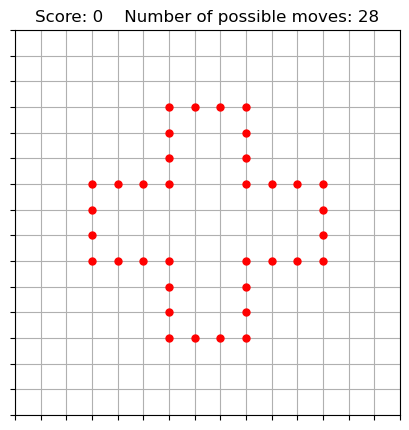

In [2]:
game = Game5T('c')
game.print()

Play a specific move:

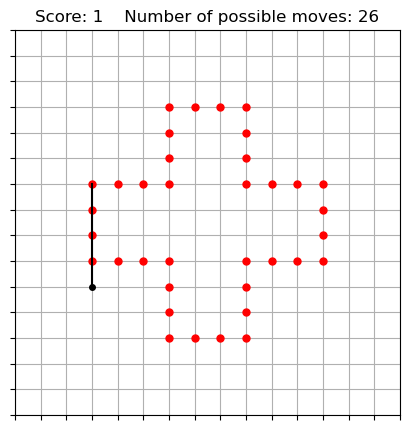

In [3]:
game.playByIndex(0)
game.print()

Play a move at random:

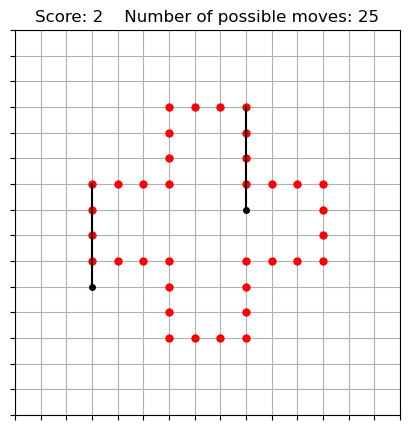

In [4]:
game.playAtRandom(1)
game.print()

Play several moves at random:

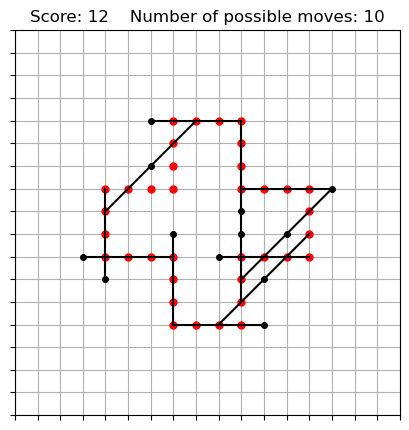

In [5]:
game.playAtRandom(10)
game.print()

Play at random until no more moves are possible:

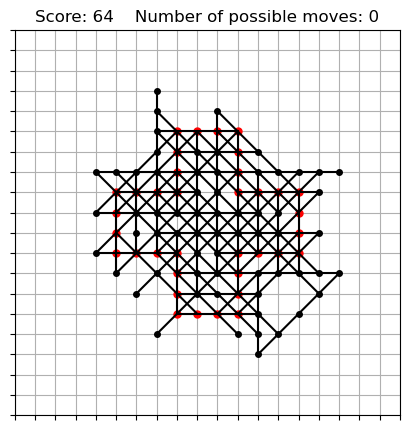

In [6]:
game.playAtRandom()
game.print()

Save game:

In [7]:
game.save('../data/test_game.json')

Undo one move:

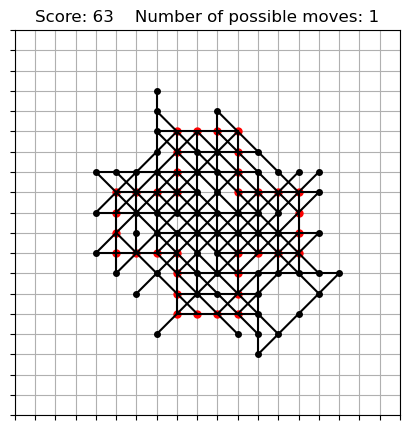

In [8]:
game.undo()
game.print()

Undo more moves:

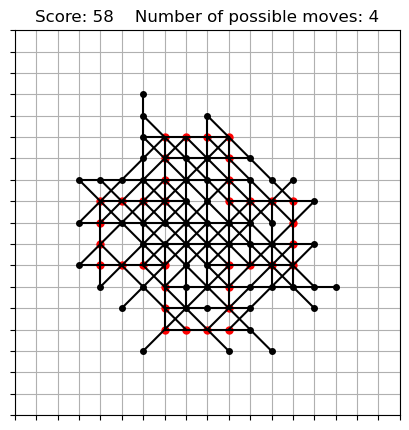

In [9]:
game.undo(5)
game.print()

Explore how many moves can still be made:

In [10]:
game.exploreDepth(5), game.exploreDepth(10)

(5, 6)

In [11]:
game.estimateDepth()

6

Load a previously saved game:

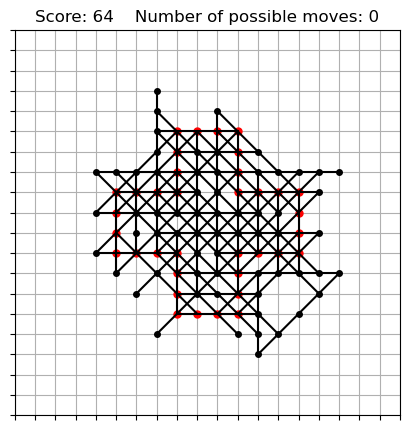

In [12]:
game = Game5T.load('../data/test_game.json')
game.print()

The state of the game is stored in a boolean array of size 192 x 192:

In [13]:
game.image().shape

(192, 192)

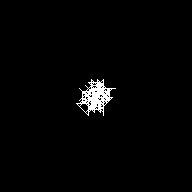

In [14]:
Image.fromarray(game.image())

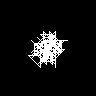

In [15]:
Image.fromarray(game.image()[48:144, 48:144])

Undo all moves to return to the starting grid:

In [16]:
game.undoAll()

Get images of all possible moves:

In [17]:
moveImages = game.getMoveImages()
moveImages.shape

(28, 192, 192)

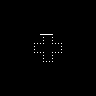

In [18]:
Image.fromarray(moveImages[0, 48:144, 48:144])

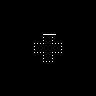

In [19]:
Image.fromarray(moveImages[1, 48:144, 48:144])

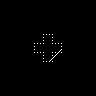

In [20]:
Image.fromarray(moveImages[-1, 48:144, 48:144])

A particula move can be highlighted with:

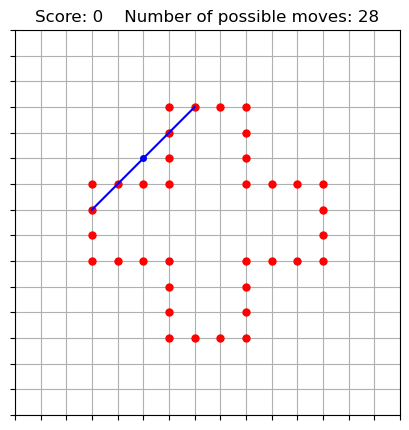

In [21]:
game.undoAll()
game.printMove(24)

Forbid a particular move forever:

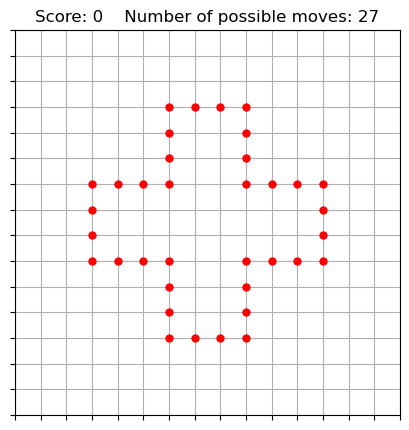

In [22]:
game.deleteMoveByIndex(24)
game.print()

The deleted move will never be playable again:

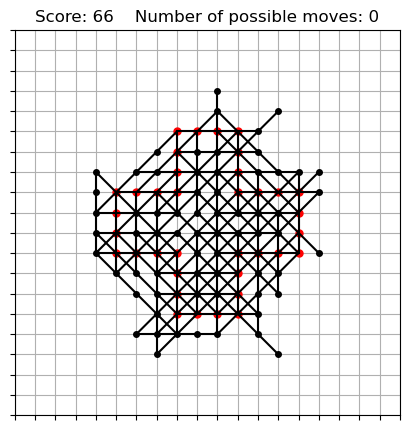

In [23]:
game.playAtRandom()
game.print()

Even after returing to the start grid, only 27 out of usual 28 moves are playable:

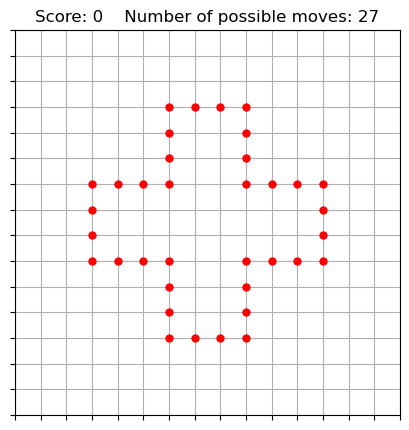

In [24]:
game.undoAll()
game.print()

To reset the game and recover all deleted moves, use the following:

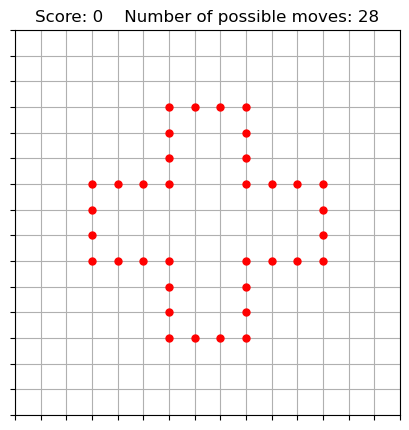

In [25]:
game.restart()
game.print()

Play using the nested Monte-Carlo algorithm:

CPU times: user 230 ms, sys: 2.96 ms, total: 233 ms
Wall time: 231 ms


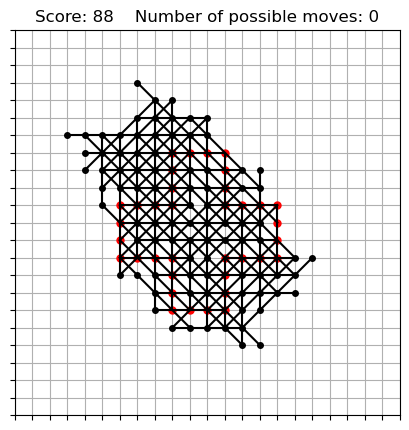

In [26]:
%%time
game.playNestedMC(1)
game.print()

CPU times: user 194 ms, sys: 2.02 ms, total: 196 ms
Wall time: 194 ms


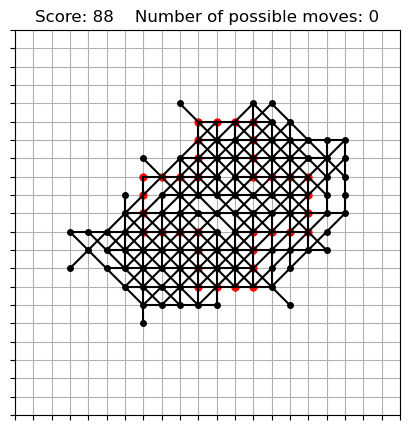

In [27]:
%%time
game.undoAll()
game.playFastNestedMC(1)
game.print()

CPU times: user 8.19 s, sys: 61.3 ms, total: 8.26 s
Wall time: 8.1 s


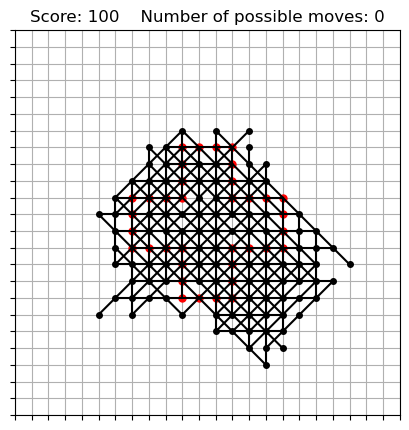

In [28]:
%%time
game.undoAll()
game.playNestedMC(2)
game.print()

CPU times: user 5.3 s, sys: 33.7 ms, total: 5.34 s
Wall time: 5.23 s


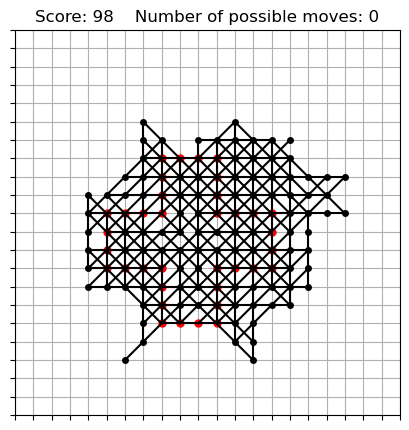

In [29]:
%%time
game.undoAll()
game.playFastNestedMC(2)
game.print()

In [30]:
# %%time
# game.undoAll()
# game.playNestedMC(3)
# game.print()

In [31]:
# %%time
# game.undoAll()
# game.playFastNestedMC(3)
# game.print()

In [32]:
# game.save('../data/highest_score.json')

In [33]:
# %%time
# game.restart()
# game.playNestedMCVariant(4)
# game.print()

Best games obtained so far:

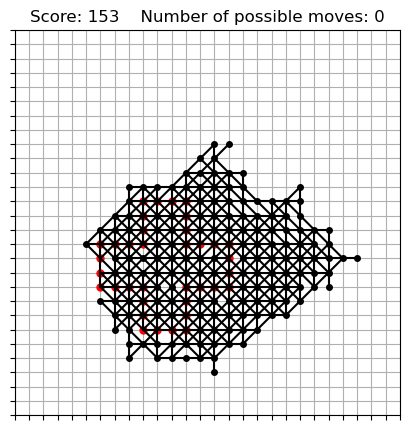

In [34]:
best_cross = Game5T.load('../data/nested-4-games/cross5T_153_54955.json')
best_cross.print()

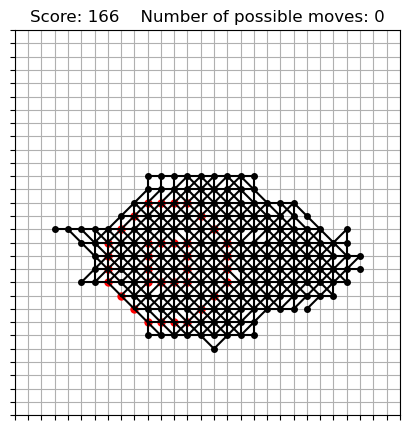

In [35]:
best_pipe = Game5T.load('../data/nested-4-games/pipe5T_166_07475.json')
best_pipe.print()

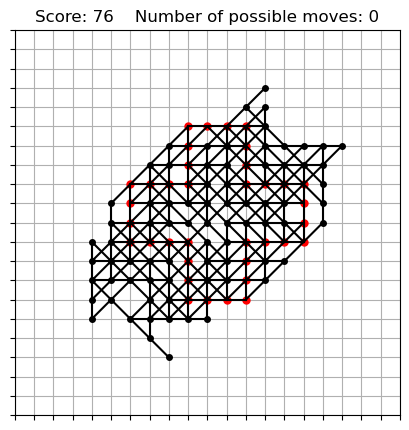

In [36]:
best_cross_D = Game5D.load('../data/nested-4-games/cross5D_076_61986.json')
best_cross_D.print()